# Machine Learning Pipeline - Feature Engineering

En los siguientes Notebooks, repasaremos la implementación de cada uno de los pasos en la Canalización de Aprendizaje Automático (ML Pipeline).

Discutiremos:

1. Data Analysis
2. **Feature Engineering**
3. Feature Selection
4. Model Training
5. Obtaining Predictions / Scoring


Usaremos el dataset de precios de casas disponible en  [Kaggle.com](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data). Consulte a continuación para más detalles.

===================================================================================================

## Predicción del Precio de Venta de Casas

El objetivo del proyecto es construir un modelo de aprendizaje automático para predecir el precio de venta de viviendas basándose en diferentes variables explicativas que describen aspectos de las casas residenciales.


### ¿Por qué es esto importante?

Predecir los precios de las casas es útil para identificar inversiones fructíferas o para determinar si el precio anunciado de una casa está sobreestimado o subestimado.

### ¿Cuál es el objetivo del modelo de aprendizaje automático?

Nuestro objetivo es minimizar la diferencia entre el precio real y el precio estimado por nuestro modelo. Evaluaremos el rendimiento del modelo con el:

1. mean squared error (MSE)
2. root squared of the mean squared error (RMSE)
3. r-squared (R2).


### ¿Cómo descargo el dataset?

- Visita [Kaggle Website](https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data).

- Recuerda hacer **log in**

- Desplázate hasta el final de la página y haz clic en el enlace **'train.csv'**, , luego haz clic en el botón azul 'descargar' hacia la derecha de la pantalla para descargar el dataset.

- Descarga el archivo llamado **'test.csv'** y guárdalo en el directorio junto con los notebooks.

**Tenga en cuenta lo siguiente:**

-  Necesita estar registrado en Kaggle para poder descargar los datasets.
-  Necesita aceptar los términos y condiciones de la competencia para descargar el dataset
-  Si guarda el archivo en el directorio junto con el cuaderno de Jupyter, entonces podrá ejecutar el código tal como está escrito aquí.

# Paso 1: Reproducibility: Setting the seed

With the aim to ensure reproducibility between runs of the same notebook, but also between the research and production environment, for each step that includes some element of randomness, it is extremely important that we **set the seed**.

In [1]:
# to handle datasets
import pandas as pd
import numpy as np

# for plotting
import matplotlib.pyplot as plt

# for the yeo-johnson transformation
import scipy.stats as stats

# to divide train and test set
from sklearn.model_selection import train_test_split

# feature scaling
from sklearn.preprocessing import MinMaxScaler

# to save the trained scaler class
import joblib

# to visualise al the columns in the dataframe
pd.pandas.set_option('display.max_columns', None)

In [2]:
# load dataset
data = pd.read_csv('../data/raw/train.csv')

# rows and columns of the data
print(data.shape)

# visualise the dataset
data.head()

(1460, 81)


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,NaN,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,NaN,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,NaN,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


# Paso 2: Separamos el Dataset en entrenamiento y prueba

Es importante separar nuestros datos en conjuntos de entrenamiento y prueba.

Cuando ingenierizamos características, algunas técnicas aprenden parámetros de los datos. Es importante aprender estos parámetros solo del conjunto de entrenamiento para evitar el sobreajuste (over-fitting).

Nuestras técnicas de ingeniería de características aprenderán:

- Media (mean)
- Moda (mode)
- Exponentes para el Yeo-Johnson (exponents for the yeo-johnson)
- Frecuencia de categorías (category frequency)
- Y mapeos de categorías a números (and category to number mappings)

del conjunto de entrenamiento.

**Separar los datos en entrenamiento y prueba implica aleatoriedad, por lo tanto, necesitamos establecer la semilla (seed).**

In [3]:
# Let's separate into train and test set
# Remember to set the seed (random_state for this sklearn function)

X_train, X_test, y_train, y_test = train_test_split(
    data.drop(['Id', 'SalePrice'], axis=1), # predictive variables
    data['SalePrice'], # target
    test_size=0.1, # portion of dataset to allocate to test set
    random_state=0, # we are setting the seed here
)

X_train.shape, X_test.shape

((1314, 79), (146, 79))

# Paso 3: Feature Engineering (Ingeniería de Características)

En las siguientes celdas, procesaremos las variables del dataset de Precios de Casas para abordar:

1. Missing values (NaN - Valores Faltantes)
2. Temporal variables (Variables Temporales)
3. Non-Gaussian distributed variables (Variables con distribución no gaussiana)
4. Categorical variables: remove rare labels (Variables categóricas: eliminar etiquetas raras)
5. Categorical variables: convert strings to numbers (Variables categóricas: convertir cadenas a números)
5. Put the variables in a similar scale (Poner las variables en una escala similar)

## Target

Aplicamos el logaritmo

In [4]:
y_train = np.log(y_train)
y_test = np.log(y_test)

## Missing values

### Categorical variables

Reemplazaremos los valores faltantes con el string "missing" en aquellas variables con muchos missing data (datos faltantes).

Alternativamente, reemplazaremos los datos faltantes con la categoría más frecuente en aquellas variables que contienen menos observaciones sin valores.

Esto es una práctica común.

##### Cantidad de Variables Categoricas

In [5]:
# Identificamos las variables categóricas
# Capturaremos aquellas de tipo objeto

cat_vars = [var for var in data.columns if data[var].dtype == 'O']

# MSSubClass también es categórica por definición, a pesar de sus valores numéricos
# (puedes encontrar las definiciones de las variables en el archivo data_description.txt
# disponible en Kaggle, en el mismo sitio web donde descargaste los datos)

# agreguemos MSSubClass a la lista de variables categóricas
cat_vars = cat_vars + ['MSSubClass']

# convertir todas las variables a categóricas
X_train[cat_vars] = X_train[cat_vars].astype('O')
X_test[cat_vars] = X_test[cat_vars].astype('O')

# Numero de Variables Categóricas
print(f"Cantidad de Variables Categóricas: {len(cat_vars)}")

Cantidad de Variables Categóricas: 44


##### Variables Categóricas con Missing Values

In [6]:
# Hacemos una lista de las Variables Categóricas que contienen missing values

cat_vars_with_na = [
    var for var in cat_vars
    if X_train[var].isnull().sum() > 0
]

# Imprimimos el porcentaje de missing values por Variable
X_train[cat_vars_with_na ].isnull().mean().sort_values(ascending=False)

PoolQC          0.995434
MiscFeature     0.961187
Alley           0.938356
Fence           0.814307
MasVnrType      0.601218
FireplaceQu     0.472603
GarageType      0.056317
GarageFinish    0.056317
GarageQual      0.056317
GarageCond      0.056317
BsmtExposure    0.025114
BsmtFinType2    0.025114
BsmtQual        0.024353
BsmtCond        0.024353
BsmtFinType1    0.024353
Electrical      0.000761
dtype: float64

### Imputamos Variables con: A) La Etiqueta o String "Missing" y con la B) Frecuencia (Categoría más frecuente)

In [7]:
# Variables para imputar con el string missing
with_string_missing = [
    var for var in cat_vars_with_na if X_train[var].isnull().mean() > 0.1]

# Variables para imputar con la categoría más frecuente
with_frequent_category = [
    var for var in cat_vars_with_na if X_train[var].isnull().mean() < 0.1]

### Variables para imputar con la Etiqueta Missing

In [8]:
with_string_missing

['Alley', 'MasVnrType', 'FireplaceQu', 'PoolQC', 'Fence', 'MiscFeature']

### Imputamos con la Etiqueta Missing

In [9]:
# Reemplazar los valores faltantes con la nueva etiqueta: "Missing"

X_train[with_string_missing] = X_train[with_string_missing].fillna('Missing')
X_test[with_string_missing] = X_test[with_string_missing].fillna('Missing')

### Buscamos la Etiqueta más Frecuente en las Variables (Moda) e Imputamos

In [10]:
for var in with_frequent_category:

    # puede haber más de una moda en una variable
    # tomamos la primera con [0]
    mode = X_train[var].mode()[0]

    print(f"La moda de la variable {var} es {mode}")

    X_train[var] = X_train[var].fillna(mode)
    X_test[var] = X_test[var].fillna(mode)

La moda de la variable BsmtQual es TA
La moda de la variable BsmtCond es TA
La moda de la variable BsmtExposure es No
La moda de la variable BsmtFinType1 es Unf
La moda de la variable BsmtFinType2 es Unf
La moda de la variable Electrical es SBrkr
La moda de la variable GarageType es Attchd
La moda de la variable GarageFinish es Unf
La moda de la variable GarageQual es TA
La moda de la variable GarageCond es TA


### Verificamos que no haya Missing Values en las Variables Imputadas

In [ ]:
X_train[cat_vars_with_na].isnull().sum()

Alley           0
MasVnrType      0
BsmtQual        0
BsmtCond        0
BsmtExposure    0
BsmtFinType1    0
BsmtFinType2    0
Electrical      0
FireplaceQu     0
GarageType      0
GarageFinish    0
GarageQual      0
GarageCond      0
PoolQC          0
Fence           0
MiscFeature     0
dtype: int64

### Verificar que el conjunto de prueba no contenga valores nulos en las variables procesadas

In [ ]:
[var for var in cat_vars_with_na if X_test[var].isnull().sum() > 0]

[]

## Variables Numéricas

Para imputar los missing values en las variables numéricas, vamos a:

- agregar una variable indicadora binaria de valores faltantes
- y luego reemplazar los valores faltantes en la variable original con la media

#### Cuantas Variables Numéricas tenemos ?

In [ ]:
# Identificamos las variables numéricas
num_vars = [
    var for var in X_train.columns if X_train[var].dtype != 'O' and var != 'SalePrice'
]

# Numero de Variables Numéricas
len(num_vars)

35

In [14]:
num_vars

['LotFrontage',
 'LotArea',
 'OverallQual',
 'OverallCond',
 'YearBuilt',
 'YearRemodAdd',
 'MasVnrArea',
 'BsmtFinSF1',
 'BsmtFinSF2',
 'BsmtUnfSF',
 'TotalBsmtSF',
 '1stFlrSF',
 '2ndFlrSF',
 'LowQualFinSF',
 'GrLivArea',
 'BsmtFullBath',
 'BsmtHalfBath',
 'FullBath',
 'HalfBath',
 'BedroomAbvGr',
 'KitchenAbvGr',
 'TotRmsAbvGrd',
 'Fireplaces',
 'GarageYrBlt',
 'GarageCars',
 'GarageArea',
 'WoodDeckSF',
 'OpenPorchSF',
 'EnclosedPorch',
 '3SsnPorch',
 'ScreenPorch',
 'PoolArea',
 'MiscVal',
 'MoSold',
 'YrSold']

### Variables Numéricas con Missing Values

In [15]:
# hacer una lista con las variables numéricas que contienen valores faltantes
vars_with_na = [
    var for var in num_vars
    if X_train[var].isnull().sum() > 0
]

# imprimir el porcentaje de valores faltantes por variable
X_train[vars_with_na].isnull().mean()

LotFrontage    0.177321
MasVnrArea     0.004566
GarageYrBlt    0.056317
dtype: float64

### Imputamos con la Media

In [16]:
for var in vars_with_na:

    # calculamos la media usando el conjunto de entrenamiento
    mean_val = X_train[var].mean()

    print(f"La media de la variable {var} es {mean_val}")

    # agregar un indicador binario de valores faltantes (en entrenamiento y prueba)
    X_train[var + '_na'] = np.where(X_train[var].isnull(), 1, 0)
    X_test[var + '_na'] = np.where(X_test[var].isnull(), 1, 0)

    # Reemplazamos los missing values por la MEDIA
    # (en train y test)
    X_train[var] = X_train[var].fillna(mean_val)
    X_test[var] = X_test[var].fillna(mean_val)

# verificar que no tengamos más valores faltantes en las variables procesadas
X_train[vars_with_na].isnull().sum()

La media de la variable LotFrontage es 69.87974098057354
La media de la variable MasVnrArea es 103.7974006116208
La media de la variable GarageYrBlt es 1978.2959677419356


LotFrontage    0
MasVnrArea     0
GarageYrBlt    0
dtype: int64

### verificamos que el conjunto de prueba no contenga valores nulos en las variables procesadas

In [ ]:
[var for var in vars_with_na if X_test[var].isnull().sum() > 0]

[]

### verificamos las variables indicadoras binarias de valores faltantes

In [ ]:
X_train[['LotFrontage_na', 'MasVnrArea_na', 'GarageYrBlt_na']].head()

,LotFrontage_na,MasVnrArea_na,GarageYrBlt_na
930,0,0,0
656,0,0,0
45,0,0,0
1348,1,0,0
55,0,0,0


## Temporal variables

### Capturamos tiempo transcurrido (Capture elapsed time)

Aprendimos en el Notebook anterior que hay 4 variables que se refieren a los años en los que la casa o el garaje fueron construidos o remodelados.

Capturaremos el tiempo transcurrido entre esas variables y el año en que la casa fue vendida:

In [19]:
def elapsed_years(df, var):
    # capture difference between the year variable
    # and the year in which the house was sold
    df[var] = df['YrSold'] - df[var]
    return df

In [20]:
for var in ['YearBuilt', 'YearRemodAdd', 'GarageYrBlt']:
    X_train = elapsed_years(X_train, var)
    X_test = elapsed_years(X_test, var)

In [21]:
# now we drop YrSold
X_train.drop(['YrSold'], axis=1, inplace=True)
X_test.drop(['YrSold'], axis=1, inplace=True)

## Transformación de las Variables Numéricas

### Transformación Logarítmica

In the previous notebook, we observed that the numerical variables are not normally distributed.

We will transform with the logarightm the positive numerical variables in order to get a more Gaussian-like distribution.

In [22]:
for var in ["LotFrontage", "1stFlrSF", "GrLivArea"]:
    X_train[var] = np.log(X_train[var])
    X_test[var] = np.log(X_test[var])

#### Verificamos el Conjunto de Test no contenga Missing Values en las Variables Procesadas

In [ ]:
[var for var in ["LotFrontage", "1stFlrSF", "GrLivArea"] if X_test[var].isnull().sum() > 0]

[]

#### Verificamos el Conjunto de Train no contenga Missing Values en las Variables Procesadas

In [ ]:
[var for var in ["LotFrontage", "1stFlrSF", "GrLivArea"] if X_train[var].isnull().sum() > 0]

[]

### Transformación Yeo-Johnson

We will apply the Yeo-Johnson transformation to LotArea.

La Transformación Yeo-Johnson aprende el mejor exponente para transformar la variable.
Ese exponente se aprende con el Conjunto de Entrenamiento

In [ ]:
X_train['LotArea'], param = stats.yeojohnson(X_train['LotArea'])

# and then apply the transformation to the test set with the same
# parameter: see who this time we pass param as argument to the
# yeo-johnson
X_test['LotArea'] = stats.yeojohnson(X_test['LotArea'], lmbda=param)

print(param)

0.017755558882009546


#### Verificamos el Conjunto de Train no contenga Missing Values en las Variables Procesadas

In [26]:
# check absence of na in the train set
[var for var in X_train.columns if X_train[var].isnull().sum() > 0]

[]

#### Verificamos el Conjunto de Test no contenga Missing Values en las Variables Procesadas

In [ ]:
[var for var in X_train.columns if X_test[var].isnull().sum() > 0]

[]

### Binarizamos las Variables Skewed (sesgadas)

Había algunas variables muy sesgadas, las transformaremos en variables binarias.

In [28]:
skewed = [
    'BsmtFinSF2', 'LowQualFinSF', 'EnclosedPorch',
    '3SsnPorch', 'ScreenPorch', 'MiscVal'
]

for var in skewed:

    # map the variable values into 0 and 1
    X_train[var] = np.where(X_train[var]==0, 0, 1)
    X_test[var] = np.where(X_test[var]==0, 0, 1)

## Variables categóricas

### Aplicamos mapeos

Estas son variables cuyos valores tienen un orden asignado, relacionado con la calidad. Para más información, consulta el sitio web de Kaggle.

In [29]:
# re-map strings to numbers, which determine quality

qual_mappings = {'Po': 1, 'Fa': 2, 'TA': 3, 'Gd': 4, 'Ex': 5, 'Missing': 0, 'NA': 0}

qual_vars = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond',
             'HeatingQC', 'KitchenQual', 'FireplaceQu',
             'GarageQual', 'GarageCond',
            ]

for var in qual_vars:
    X_train[var] = X_train[var].map(qual_mappings)
    X_test[var] = X_test[var].map(qual_mappings)

In [30]:
exposure_mappings = {'No': 1, 'Mn': 2, 'Av': 3, 'Gd': 4}

var = 'BsmtExposure'

X_train[var] = X_train[var].map(exposure_mappings)
X_test[var] = X_test[var].map(exposure_mappings)

In [31]:
finish_mappings = {'Missing': 0, 'NA': 0, 'Unf': 1, 'LwQ': 2, 'Rec': 3, 'BLQ': 4, 'ALQ': 5, 'GLQ': 6}

finish_vars = ['BsmtFinType1', 'BsmtFinType2']

for var in finish_vars:
    X_train[var] = X_train[var].map(finish_mappings)
    X_test[var] = X_test[var].map(finish_mappings)

In [32]:
garage_mappings = {'Missing': 0, 'NA': 0, 'Unf': 1, 'RFn': 2, 'Fin': 3}

var = 'GarageFinish'

X_train[var] = X_train[var].map(garage_mappings)
X_test[var] = X_test[var].map(garage_mappings)

In [33]:
fence_mappings = {'Missing': 0, 'NA': 0, 'MnWw': 1, 'GdWo': 2, 'MnPrv': 3, 'GdPrv': 4}

var = 'Fence'

X_train[var] = X_train[var].map(fence_mappings)
X_test[var] = X_test[var].map(fence_mappings)

In [34]:
# check absence of na in the train set
[var for var in X_train.columns if X_train[var].isnull().sum() > 0]

[]

### Eliminación de etiquetas raras

Para las variables categóricas restantes, agruparemos aquellas categorías que están presentes en menos del 1% de las observaciones. Es decir, todos los valores de las variables categóricas que son compartidos por menos del 1% de las casas serán reemplazados por la cadena "Raro".

In [ ]:
# Capturamos todas las Variables de Calidad

qual_vars  = qual_vars + finish_vars + ['BsmtExposure','GarageFinish','Fence']

cat_others = [
    var for var in cat_vars if var not in qual_vars
]

len(cat_others)

30

In [36]:
def find_frequent_labels(df, var, rare_perc):

    # función que encuentra las etiquetas que son compartidas por más de
    # un cierto % de las casas en el conjunto de datos

    df = df.copy()

    tmp = df.groupby(var)[var].count() / len(df)

    return tmp[tmp > rare_perc].index


for var in cat_others:

    # find the frequent categories
    frequent_ls = find_frequent_labels(X_train, var, 0.01)

    print(var, frequent_ls)
    print()

    # replace rare categories by the string "Rare"
    X_train[var] = np.where(X_train[var].isin(
        frequent_ls), X_train[var], 'Rare')

    X_test[var] = np.where(X_test[var].isin(
        frequent_ls), X_test[var], 'Rare')

MSZoning Index(['FV', 'RH', 'RL', 'RM'], dtype='object', name='MSZoning')

Street Index(['Pave'], dtype='object', name='Street')

Alley Index(['Grvl', 'Missing', 'Pave'], dtype='object', name='Alley')

LotShape Index(['IR1', 'IR2', 'Reg'], dtype='object', name='LotShape')

LandContour Index(['Bnk', 'HLS', 'Low', 'Lvl'], dtype='object', name='LandContour')

Utilities Index(['AllPub'], dtype='object', name='Utilities')

LotConfig Index(['Corner', 'CulDSac', 'FR2', 'Inside'], dtype='object', name='LotConfig')

LandSlope Index(['Gtl', 'Mod'], dtype='object', name='LandSlope')

Neighborhood Index(['Blmngtn', 'BrDale', 'BrkSide', 'ClearCr', 'CollgCr', 'Crawfor',
       'Edwards', 'Gilbert', 'IDOTRR', 'MeadowV', 'Mitchel', 'NAmes', 'NWAmes',
       'NoRidge', 'NridgHt', 'OldTown', 'SWISU', 'Sawyer', 'SawyerW',
       'Somerst', 'StoneBr', 'Timber'],
      dtype='object', name='Neighborhood')

Condition1 Index(['Artery', 'Feedr', 'Norm', 'PosN', 'RRAn'], dtype='object', name='Condition1')

Con

### Codificación de las Variables Categóricas

A continuación, necesitamos transformar las cadenas de las variables categóricas en números.

Lo haremos para capturar la relación monótona entre la etiqueta y el objetivo.

In [37]:
# esta función asignará valores discretos a las cadenas de las variables,
# de modo que el valor más pequeño corresponda a la categoría que muestra el menor
# precio medio de venta de casas

def replace_categories(train, test, y_train, var, target):

    tmp = pd.concat([X_train, y_train], axis=1)

    # order the categories in a variable from that with the lowest
    # house sale price, to that with the highest
    ordered_labels = tmp.groupby([var])[target].mean().sort_values().index

    # create a dictionary of ordered categories to integer values
    ordinal_label = {k: i for i, k in enumerate(ordered_labels, 0)}

    print(var, ordinal_label)
    print()

    # use the dictionary to replace the categorical strings by integers
    train[var] = train[var].map(ordinal_label)
    test[var] = test[var].map(ordinal_label)

In [38]:
for var in cat_others:
    replace_categories(X_train, X_test, y_train, var, 'SalePrice')

MSZoning {'Rare': 0, 'RM': 1, 'RH': 2, 'RL': 3, 'FV': 4}

Street {'Rare': 0, 'Pave': 1}

Alley {'Grvl': 0, 'Pave': 1, 'Missing': 2}

LotShape {'Reg': 0, 'IR1': 1, 'Rare': 2, 'IR2': 3}

LandContour {'Bnk': 0, 'Lvl': 1, 'Low': 2, 'HLS': 3}

Utilities {'Rare': 0, 'AllPub': 1}

LotConfig {'Inside': 0, 'FR2': 1, 'Corner': 2, 'Rare': 3, 'CulDSac': 4}

LandSlope {'Gtl': 0, 'Mod': 1, 'Rare': 2}

Neighborhood {'IDOTRR': 0, 'MeadowV': 1, 'BrDale': 2, 'Edwards': 3, 'BrkSide': 4, 'OldTown': 5, 'Sawyer': 6, 'SWISU': 7, 'NAmes': 8, 'Mitchel': 9, 'SawyerW': 10, 'Rare': 11, 'NWAmes': 12, 'Gilbert': 13, 'Blmngtn': 14, 'CollgCr': 15, 'Crawfor': 16, 'ClearCr': 17, 'Somerst': 18, 'Timber': 19, 'StoneBr': 20, 'NridgHt': 21, 'NoRidge': 22}

Condition1 {'Artery': 0, 'Feedr': 1, 'Norm': 2, 'RRAn': 3, 'Rare': 4, 'PosN': 5}

Condition2 {'Rare': 0, 'Norm': 1}

BldgType {'2fmCon': 0, 'Duplex': 1, 'Twnhs': 2, '1Fam': 3, 'TwnhsE': 4}

HouseStyle {'SFoyer': 0, '1.5Fin': 1, 'Rare': 2, '1Story': 3, 'SLvl': 4, '2Story'

#### Verificamos ¿Hay valores nulos (na) en el conjunto de Entrenamiento? - NO

In [39]:
[var for var in X_train.columns if X_train[var].isnull().sum() > 0]

[]

#### Verificamos ¿Hay valores nulos (na) en el conjunto de Prueba? - NO

In [40]:
[var for var in X_test.columns if X_test[var].isnull().sum() > 0]

[]

### Veamos la relación monótona (monotonic relationship) entre etiquetas y objetivo

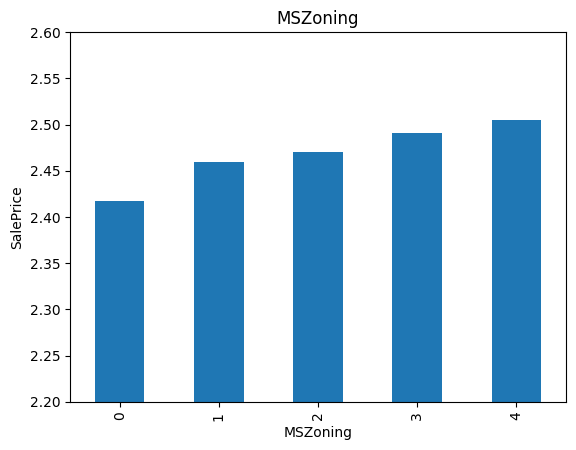

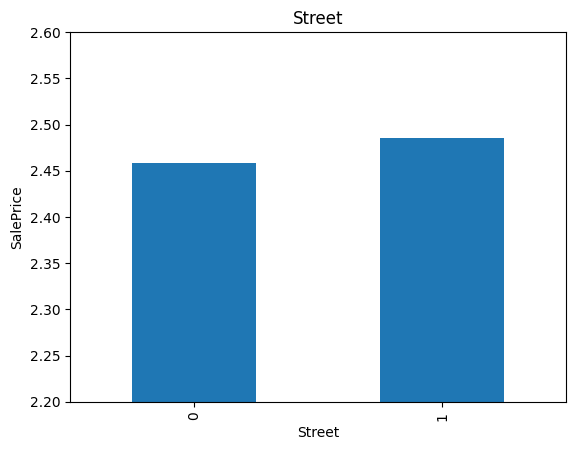

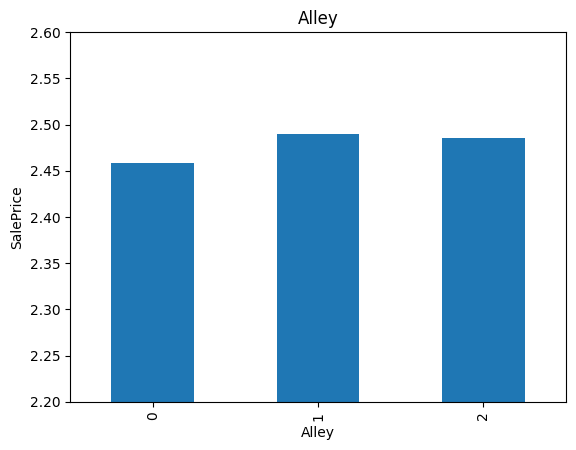

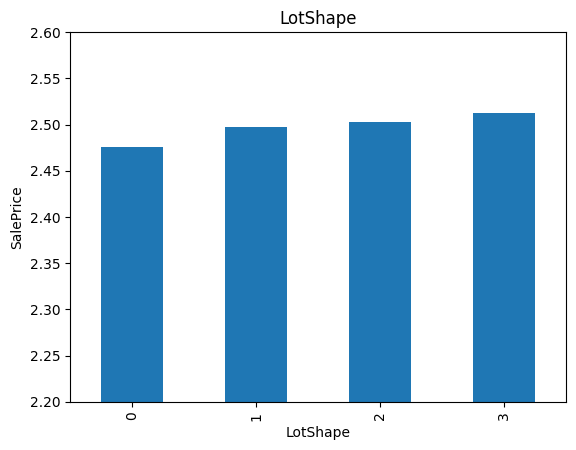

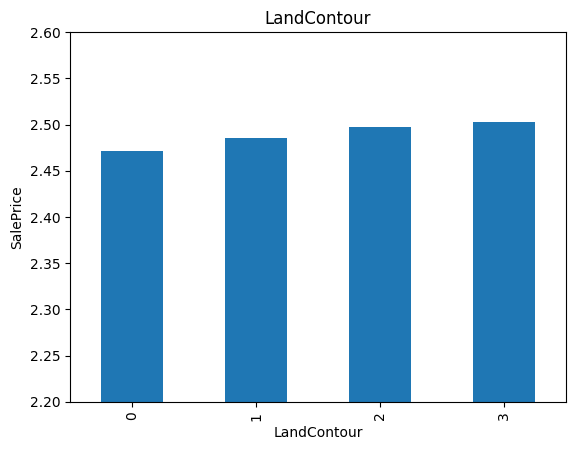

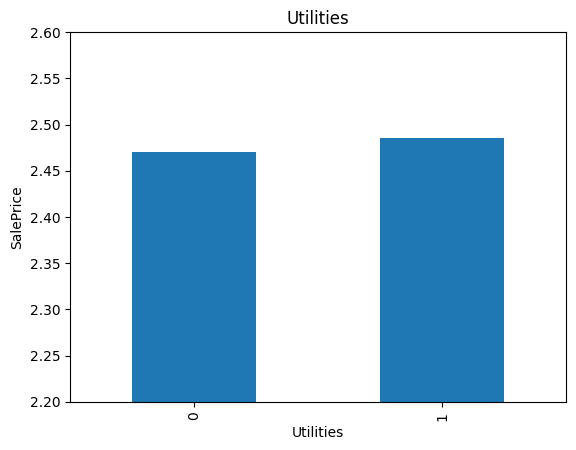

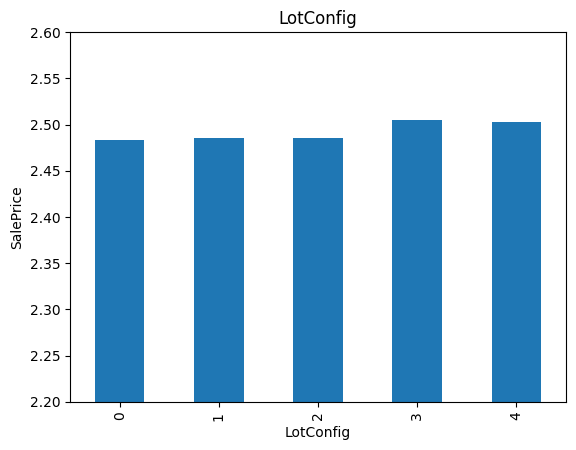

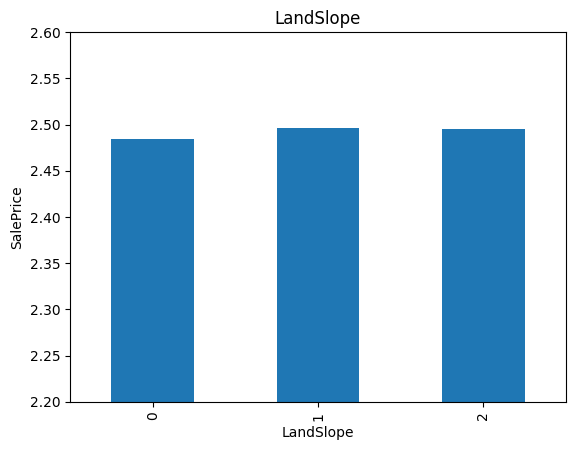

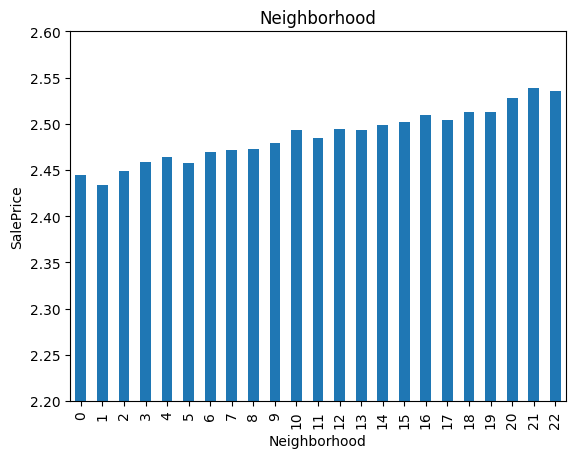

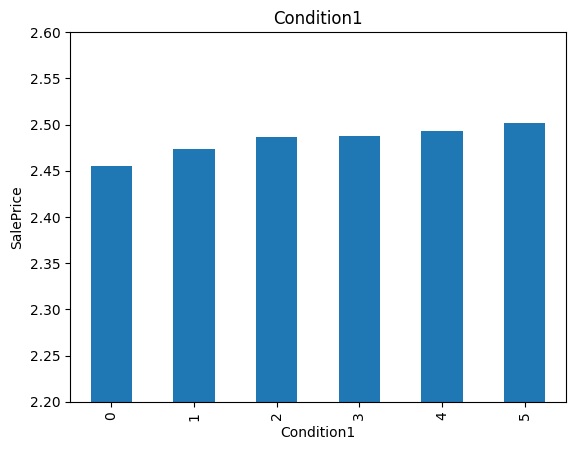

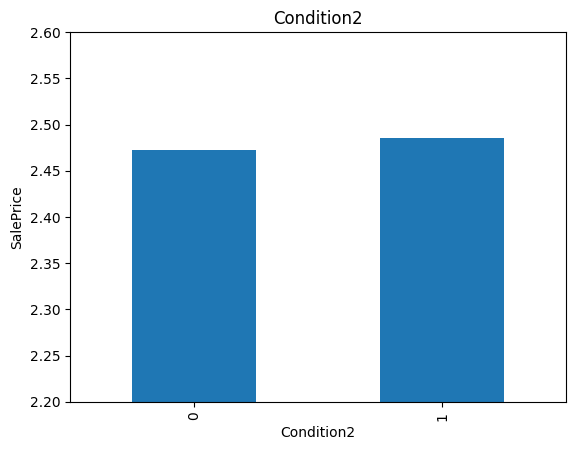

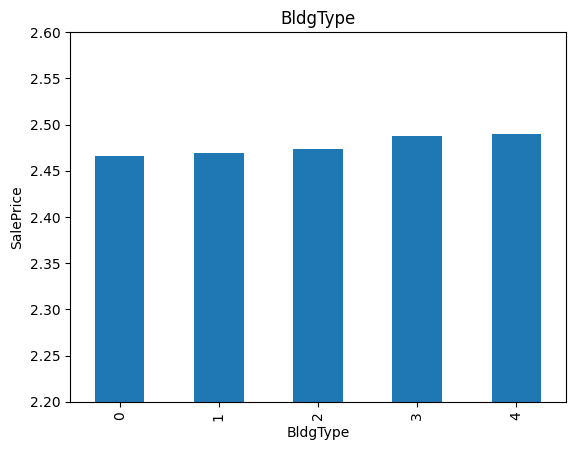

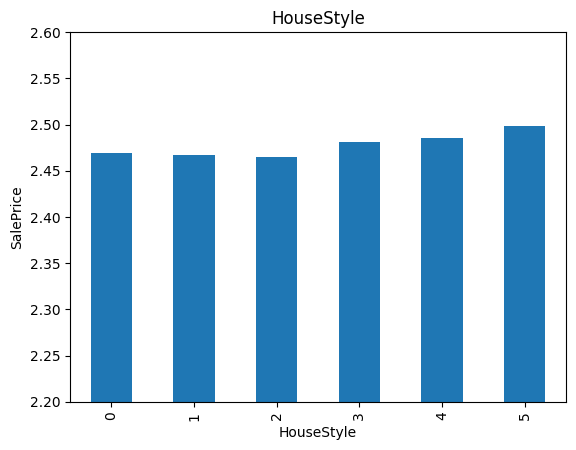

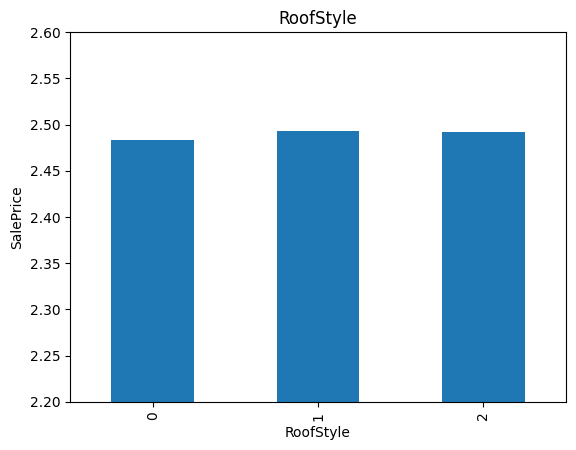

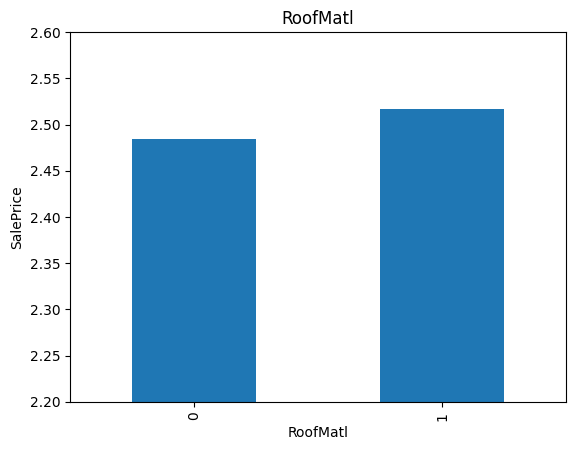

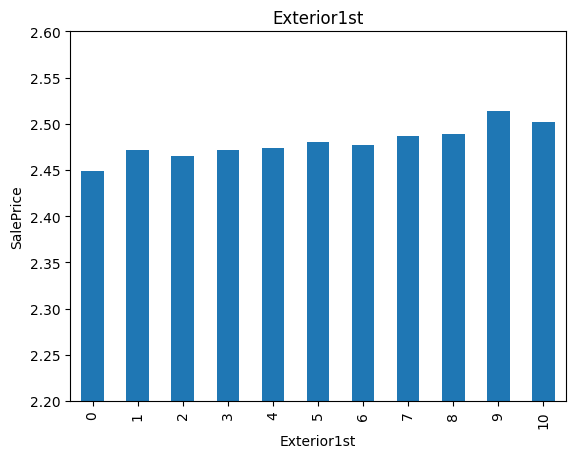

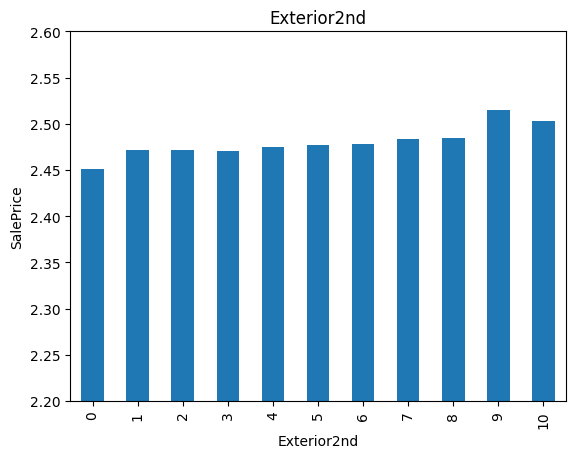

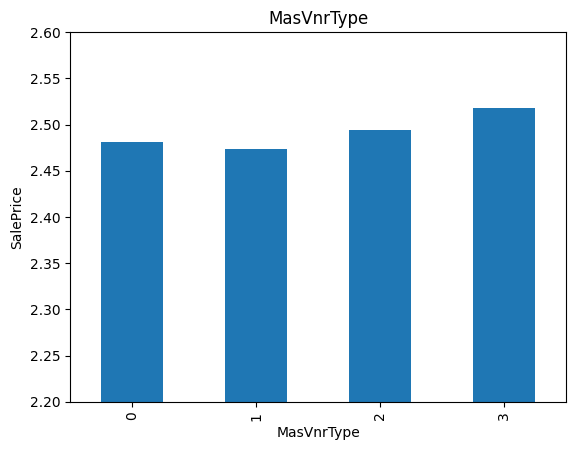

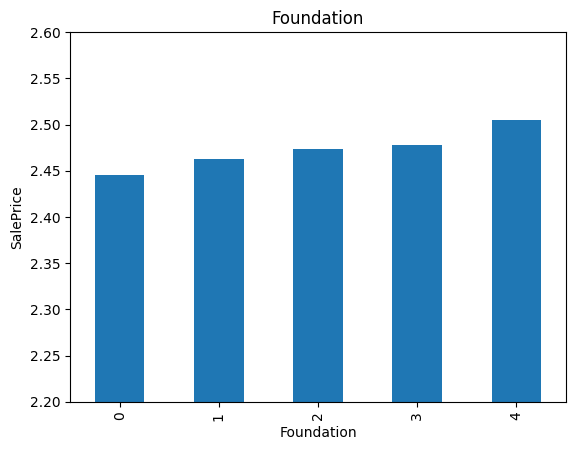

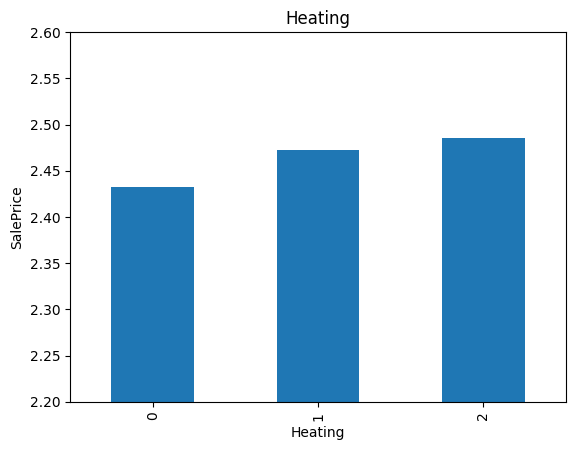

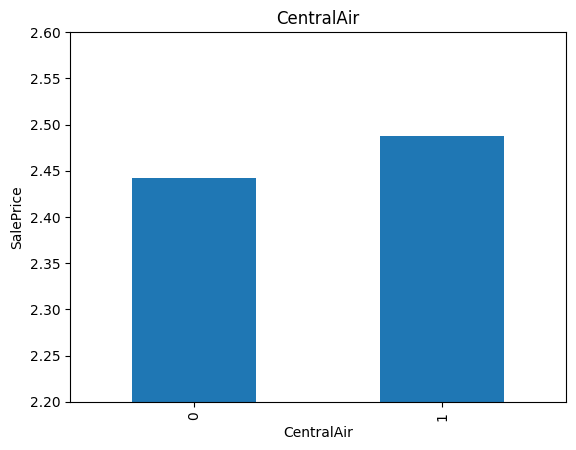

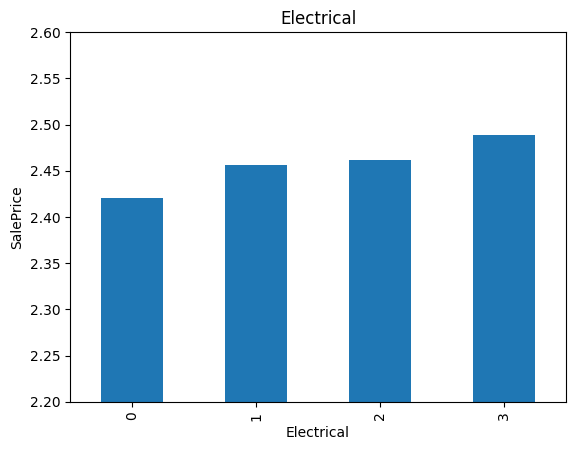

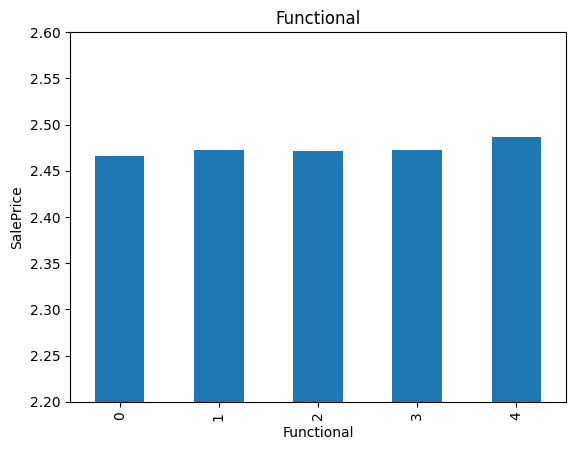

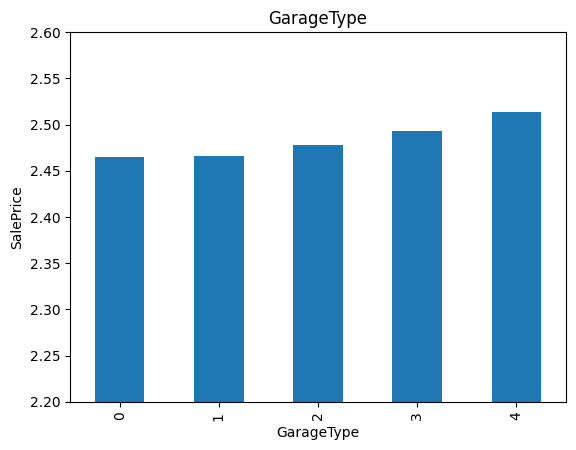

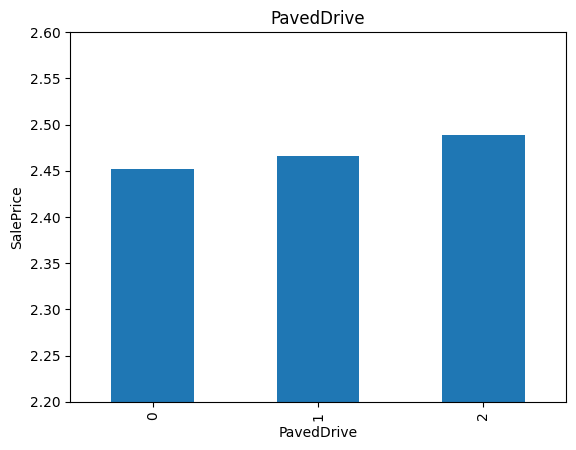

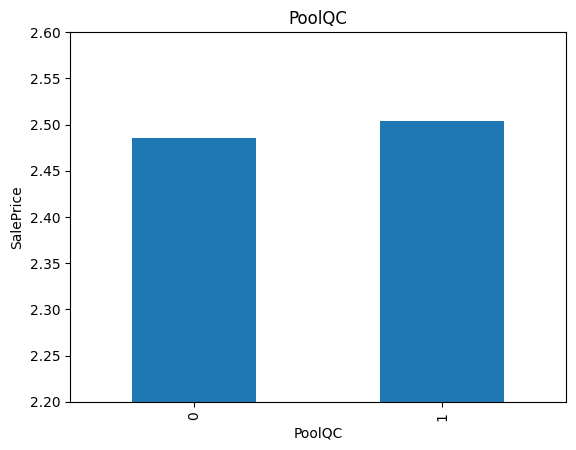

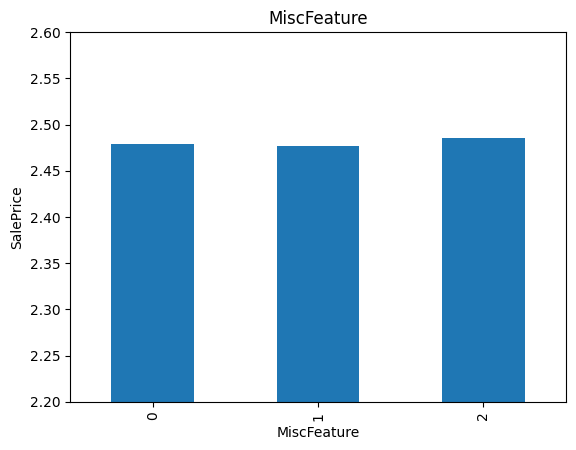

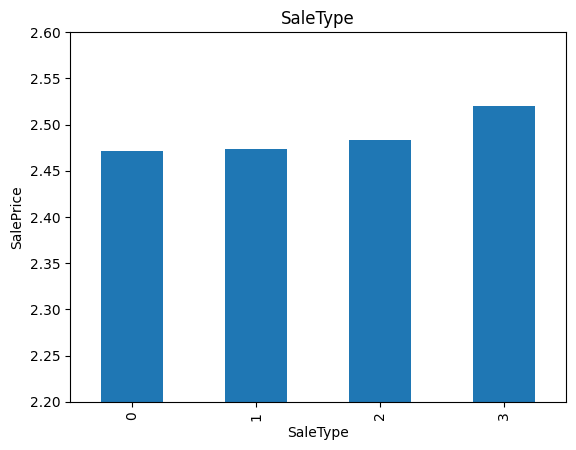

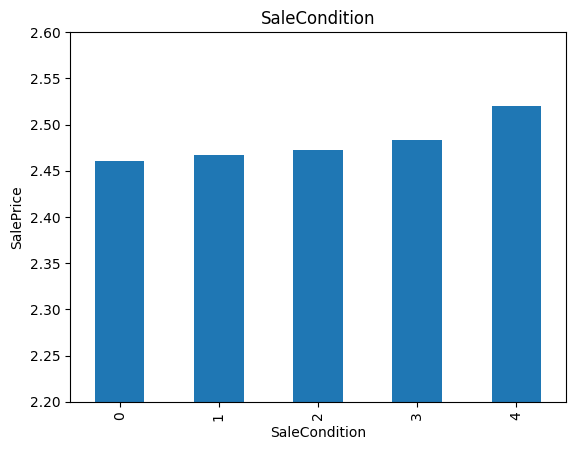

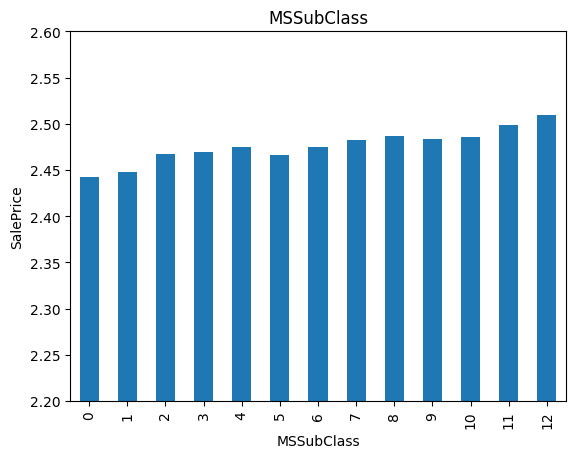

In [41]:
# déjame mostrarte a qué me refiero con relación monótona (monotonic relationship)
# entre etiquetas y objetivo

def analyse_vars(train, y_train, var):

    # función que grafica el precio medio de venta de casas por categoría codificada

    tmp = pd.concat([X_train, np.log(y_train)], axis=1)

    tmp.groupby(var)['SalePrice'].median().plot.bar()
    plt.title(var)
    plt.ylim(2.2, 2.6)
    plt.ylabel('SalePrice')
    plt.show()

for var in cat_others:
    analyse_vars(X_train, y_train, var)

La relación monótona es particularmente clara para las variables MSZoning y Neighborhood. Observa cómo, cuanto mayor es el número entero que ahora representa la categoría, mayor es el precio medio de venta de casas.

(recuerda que el objetivo está transformado logarítmicamente, por eso las diferencias parecen tan pequeñas).

## Feature Scaling (Escalamiento de las Características)

Para su uso en modelos lineales, las características deben ser escaladas. Escalaremos las características a los valores mínimos y máximos:

In [42]:
if isinstance(X_train, pd.DataFrame):
    print("X_train es un DataFrame de pandas")
else:
    print("X_train no es un DataFrame de pandas")

X_train es un DataFrame de pandas


In [43]:
print(len(X_train))
print(X_train.shape)

1314
(1314, 81)


In [44]:
# Creamos el Escalador (Scaler)
scaler = MinMaxScaler()

# Ajustamos el Scaler para el Conjunto de Entrenamiento
scaler.fit(X_train)

# Transformamos el conjunto de entrenamiento y el conjunto de prueba

# sklearn devuelve arrays de numpy, así que envolvemos el
# array con un dataframe de pandas

X_train = pd.DataFrame(
    scaler.transform(X_train),
    columns=X_train.columns
)

X_test = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_train.columns
)

In [45]:
X_train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,SaleType,SaleCondition,LotFrontage_na,MasVnrArea_na,GarageYrBlt_na
0,0.750000,0.75,0.461171,0.366365,1.0,1.0,0.333333,1.000000,1.0,0.0,0.0,0.863636,0.4,1.0,0.75,0.6,0.777778,0.50,0.014706,0.049180,0.0,0.0,1.0,1.0,0.333333,0.00000,0.666667,0.5,1.0,0.666667,0.666667,0.666667,1.0,0.002835,0.0,0.0,0.673479,0.239935,1.0,1.00,1.0,1.0,0.559760,0.0,0.0,0.523250,0.000000,0.0,0.666667,0.0,0.375,0.333333,0.666667,0.416667,1.0,0.000000,0.0,0.75,0.018692,1.0,0.75,0.430183,0.5,0.5,1.0,0.116686,0.032907,0.0,0.0,0.0,0.0,0.0,0.00,1.0,0.0,0.545455,0.666667,0.75,0.0,0.0,0.0
1,0.750000,0.75,0.456066,0.388528,1.0,1.0,0.333333,0.333333,1.0,0.0,0.0,0.363636,0.4,1.0,0.75,0.6,0.444444,0.75,0.360294,0.049180,0.0,0.0,0.6,0.6,0.666667,0.03375,0.666667,0.5,0.5,0.333333,0.666667,0.000000,0.8,0.142807,0.0,0.0,0.114724,0.172340,1.0,1.00,1.0,1.0,0.434539,0.0,0.0,0.406196,0.333333,0.0,0.333333,0.5,0.375,0.333333,0.666667,0.250000,1.0,0.000000,0.0,0.75,0.457944,0.5,0.25,0.220028,0.5,0.5,1.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0,0.75,1.0,0.0,0.636364,0.666667,0.75,0.0,0.0,0.0
2,0.916667,0.75,0.394699,0.336782,1.0,1.0,0.000000,0.333333,1.0,0.0,0.0,0.954545,0.4,1.0,1.00,0.6,0.888889,0.50,0.036765,0.098361,1.0,0.0,0.3,0.2,0.666667,0.25750,1.000000,0.5,1.0,1.000000,0.666667,0.000000,1.0,0.080794,0.0,0.0,0.601951,0.286743,1.0,1.00,1.0,1.0,0.627205,0.0,0.0,0.586296,0.333333,0.0,0.666667,0.0,0.250,0.333333,1.000000,0.333333,1.0,0.333333,0.8,0.75,0.046729,0.5,0.50,0.406206,0.5,0.5,1.0,0.228705,0.149909,0.0,0.0,0.0,0.0,0.0,0.00,1.0,0.0,0.090909,0.666667,0.75,0.0,0.0,0.0
3,0.750000,0.75,0.445002,0.482280,1.0,1.0,0.666667,0.666667,1.0,0.0,0.0,0.454545,0.4,1.0,0.75,0.6,0.666667,0.50,0.066176,0.163934,0.0,0.0,1.0,1.0,0.333333,0.00000,0.666667,0.5,1.0,0.666667,0.666667,1.000000,1.0,0.255670,0.0,0.0,0.018114,0.242553,1.0,1.00,1.0,1.0,0.566920,0.0,0.0,0.529943,0.333333,0.0,0.666667,0.0,0.375,0.333333,0.666667,0.250000,1.0,0.333333,0.4,0.75,0.084112,0.5,0.50,0.362482,0.5,0.5,1.0,0.469078,0.045704,0.0,0.0,0.0,0.0,0.0,0.00,1.0,0.0,0.636364,0.666667,0.75,1.0,0.0,0.0
4,0.750000,0.75,0.577658,0.391756,1.0,1.0,0.333333,0.333333,1.0,0.0,0.0,0.363636,0.4,1.0,0.75,0.6,0.555556,0.50,0.323529,0.737705,0.0,0.0,0.6,0.7,0.666667,0.17000,0.333333,0.5,0.5,0.333333,0.666667,0.000000,0.6,0.086818,0.0,0.0,0.434278,0.233224,1.0,0.75,1.0,1.0,0.549026,0.0,0.0,0.513216,0.000000,0.0,0.666667,0.0,0.375,0.333333,0.333333,0.416667,1.0,0.333333,0.8,0.75,0.411215,0.5,0.50,0.406206,0.5,0.5,1.0,0.000000,0.000000,0.0,1.0,0.0,0.0,0.0,0.00,1.0,0.0,0.545455,0.666667,0.75,0.0,0.0,0.0


## Guardamos los datos Procesados

In [46]:
# Guardemos ahora los conjuntos de entrenamiento y prueba para el próximo Notebook!

X_train.to_csv('../data/processed/xtrain.csv', index=False)
X_test.to_csv('../data/processed/xtest.csv', index=False)

y_train.to_csv('../data/processed/ytrain.csv', index=False)
y_test.to_csv('../data/processed/ytest.csv', index=False)

## Guardamos el Escalador

In [47]:
# Ahora guardamos el Scaler

joblib.dump(scaler, '../data/processed/minmax_scaler.joblib')

['../data/processed/minmax_scaler.joblib']